DATA-SPECIFIC INFORMATION FOR: 
eaglei_outages_2023.csv 1.2 GB

1. Number of variables: 5

2. Number of cases/rows: 26101052

3. Variable List: 
 - Fips_code: The FIPS code of the county in which the power outages occurred, for example “12011”
 - County: The county name in which the power outages occurred spelled out in text, for example “Broward”
 - State: The state in which the power outage occurred, spelled out in full in text format. For example, “Florida”
 - Sum: The total number of customers without power for that county at that timestamp. This number is always an integer. Entries with 0 customers without power were not included in this dataset. Note that the number of “customers” does not necessarily equate to the number of people affected, as a “customer” reported by a utility could be one meter, one building, etc. Outages are collected at various different levels of resolution (county, point, zip code, and polygon) and are aggregated to county for consistent reporting.
 - Run_start_time: Date and timestamp provided in GMT in the format “MM/DD/YY 00:00”. EAGLE-I collects power outage information from all covered utilities at 15-minute intervals, and this timestamp marks the beginning of the collection run.


In [2]:
import os, sys

import pandas as pd
import numpy as np

import geopandas as gpd


import plotly.express as px
import json

import matplotlib.pyplot as plt

import time

import glob

import imageio.v2 as imageio  # For creating a GIF


In [90]:
directory = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/'
file = 'outage_data_2023.csv'

data = pd.read_csv(os.path.join(directory,file))
data.head()

data['datetime'] = pd.to_datetime(data['run_start_time'], errors='coerce')  # Handle any invalid dates

# Define start and end dates
start_date = '2023-03-31'
end_date = '2023-04-04'

# Filter rows that fall within the date range
filtered_data = data[(data['datetime'] >= start_date) & (data['datetime'] <= end_date)]




In [3]:
directory = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/EAGLE-I/'
file = 'eaglei_outages_2024.csv'

data = pd.read_csv(os.path.join(directory,file))
data.head()

data['datetime'] = pd.to_datetime(data['run_start_time'], errors='coerce')  # Handle any invalid dates

# Define start and end dates
start_date = '2024-01-01'
end_date = '2024-12-31'

# Filter rows that fall within the date range
filtered_data = data[(data['datetime'] >= start_date) & (data['datetime'] <= end_date)]




In [12]:
pd.unique(filtered_data['state'])

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana',
       'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi',
       'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire',
       'New Jersey', 'New Mexico', 'New York', 'North Carolina',
       'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
       'Puerto Rico', 'South Carolina', 'South Dakota', 'Tennessee',
       'Texas', 'United States Virgin Islands', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming',
       'Rhode Island'], dtype=object)

In [4]:

# Load the US County GeoJSON file
geojson_url = "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
geojson = json.loads(pd.read_json(geojson_url).to_json())
counties_gdf = gpd.read_file(geojson_url)

# geojson_file = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/location_data/counties.geojson"
# geojson = json.loads(pd.read_json(geojson_url).to_json())


In [60]:
counties_gdf.head()

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry
0,01001,0500000US01001,01,001,Autauga,County,594.436,"POLYGON ((-86.49677 32.34444, -86.71790 32.402..."
1,01009,0500000US01009,01,009,Blount,County,644.776,"POLYGON ((-86.57780 33.76532, -86.75914 33.840..."
2,01017,0500000US01017,01,017,Chambers,County,596.531,"POLYGON ((-85.18413 32.87053, -85.12342 32.772..."
3,01021,0500000US01021,01,021,Chilton,County,692.854,"POLYGON ((-86.51734 33.02057, -86.51596 32.929..."
4,01033,0500000US01033,01,033,Colbert,County,592.619,"POLYGON ((-88.13999 34.58170, -88.13925 34.587..."


In [61]:
counties_gdf['fips_code'] = pd.to_numeric(counties_gdf['id'], downcast='integer', errors='coerce')


In [62]:
counties_gdf.head()

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry,fips_code
0,01001,0500000US01001,01,001,Autauga,County,594.436,"POLYGON ((-86.49677 32.34444, -86.71790 32.402...",1001
1,01009,0500000US01009,01,009,Blount,County,644.776,"POLYGON ((-86.57780 33.76532, -86.75914 33.840...",1009
2,01017,0500000US01017,01,017,Chambers,County,596.531,"POLYGON ((-85.18413 32.87053, -85.12342 32.772...",1017
3,01021,0500000US01021,01,021,Chilton,County,692.854,"POLYGON ((-86.51734 33.02057, -86.51596 32.929...",1021
4,01033,0500000US01033,01,033,Colbert,County,592.619,"POLYGON ((-88.13999 34.58170, -88.13925 34.587...",1033


In [5]:
# for key, feature in geojson['features'].items():  # Iterate through dictionary keys and values
#     if "properties" in feature:  # Ensure "properties" exists
#         state_fp = feature["properties"].get("STATEFP", "")
#         county_fp = feature["properties"].get("COUNTYFP", "")
#         if state_fp and county_fp:
#             full_fips = f"{state_fp}{county_fp}"
#             feature["properties"]["fips"] = full_fips  # Add "fips" field

In [15]:
# geojson['features']['0']


In [5]:
filtered_data

,fips_code,county,state,customers_out,run_start_time,total_customers,datetime
0,1001,Autauga,Alabama,2,2024-01-01 00:15:00,29666.0,2024-01-01 00:15:00
1,1001,Autauga,Alabama,2,2024-01-01 00:30:00,29666.0,2024-01-01 00:30:00
2,1001,Autauga,Alabama,2,2024-01-01 00:45:00,29666.0,2024-01-01 00:45:00
3,1001,Autauga,Alabama,4,2024-01-02 03:15:00,29666.0,2024-01-02 03:15:00
4,1001,Autauga,Alabama,4,2024-01-02 03:30:00,29666.0,2024-01-02 03:30:00
...,...,...,...,...,...,...,...
27701290,78030,St. Thomas,United States Virgin Islands,12,2024-12-30 23:15:00,22725.0,2024-12-30 23:15:00
27701291,78030,St. Thomas,United States Virgin Islands,8,2024-12-30 23:30:00,22725.0,2024-12-30 23:30:00
27701292,78030,St. Thomas,United States Virgin Islands,4,2024-12-30 23:45:00,22725.0,2024-12-30 23:45:00
27701293,78030,St. Thomas,United States Virgin Islands,4,2024-12-31 00:00:00,22725.0,2024-12-31 00:00:00


### Perform event movie analysis

In [55]:
# Define the target datetime
target_date = pd.to_datetime("2023-03-31 00:00:00")

# Filter rows for the given datetime
time_instance_df = filtered_data[filtered_data["datetime"] == target_date]

merged_time_instance = counties_gdf.merge(time_instance_df, on="fips_code", how="left")

merged_time_instance = merged_time_instance.dropna(subset=['run_start_time'])
cols_to_fill = ['run_start_time', 'datetime']
merged_time_instance[cols_to_fill] = merged_time_instance[cols_to_fill].ffill()

# merged_with_outages["Su
merged_time_instance["sum"].fillna(0, inplace=True)

# # Plot the map
# fig, ax = plt.subplots(1, 1, figsize=(10, 6))
# merged_time_instance.boundary.plot(ax=ax, linewidth=0.5)  # Plot county boundaries
# merged_time_instance.plot(column="sum", ax=ax, cmap="OrRd", legend=True, edgecolor="black")

# ax.set_title("Power Grid Outages by County")
# plt.show()


In [56]:
merged_time_instance

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry,fips_code,county,state,sum,run_start_time,datetime
8,01079,0500000US01079,01,079,Lawrence,County,690.678,"POLYGON ((-87.10507 34.68604, -87.10591 34.587...",1079,Lawrence,Alabama,9.0,2023-03-26 00:00:00,2023-03-26
12,01121,0500000US01121,01,121,Talladega,County,736.775,"POLYGON ((-86.17437 33.10439, -86.22627 33.104...",1121,Talladega,Alabama,4.0,2023-03-26 00:00:00,2023-03-26
22,05145,0500000US05145,05,145,White,County,1035.075,"POLYGON ((-91.46511 35.08945, -91.58401 35.091...",5145,White,Arkansas,5.0,2023-03-26 00:00:00,2023-03-26
27,06055,0500000US06055,06,055,Napa,County,748.362,"POLYGON ((-122.10328 38.51335, -122.08884 38.3...",6055,Napa,California,1.0,2023-03-26 00:00:00,2023-03-26
28,06089,0500000US06089,06,089,Shasta,County,3775.402,"POLYGON ((-123.06543 40.28697, -123.06879 40.3...",6089,Shasta,California,1.0,2023-03-26 00:00:00,2023-03-26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3213,54035,0500000US54035,54,035,Jackson,County,464.348,"POLYGON ((-81.52217 38.61275, -81.63284 38.554...",54035,Jackson,West Virginia,4355.0,2023-03-26 00:00:00,2023-03-26
3214,54041,0500000US54041,54,041,Lewis,County,384.895,"POLYGON ((-80.45733 38.73917, -80.44615 38.777...",54041,Lewis,West Virginia,684.0,2023-03-26 00:00:00,2023-03-26
3217,51021,0500000US51021,51,021,Bland,County,357.725,"POLYGON ((-81.22510 37.23487, -81.20477 37.243...",51021,Bland,Virginia,58.0,2023-03-26 00:00:00,2023-03-26
3218,51027,0500000US51027,51,027,Buchanan,County,502.763,"POLYGON ((-81.96830 37.53780, -81.92787 37.512...",51027,Buchanan,Virginia,4.0,2023-03-26 00:00:00,2023-03-26


In [98]:
filtered_data_copy = filtered_data.copy(deep=True)

In [168]:


# Visualize an outage event


# Create a list and directory to store frames
frame_files = []
dir_frames = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_frames"
os.makedirs(dir_frames, exist_ok=True)

# Loop through each datetime and update the color of each county
for i, time_step in enumerate(filtered_data['run_start_time'].unique()[0::4]):#:16]:

    time_step_df = filtered_data_copy[filtered_data_copy["datetime"] == pd.to_datetime(time_step)]

    time_step_merged = counties_gdf.merge(time_step_df, on='fips_code', how='left')
    cols_to_fill = ['run_start_time', 'datetime']
    time_step_merged[cols_to_fill] = time_step_merged[cols_to_fill].ffill()
    
    time_step_merged['run_start_time'].fillna(time_step, inplace=True)
    time_step_merged['datetime'].fillna(target_date, inplace=True)
    time_step_merged['sum'].fillna(0, inplace=True)


    # Create an animated choropleth map using Plotly Express
    fig = px.choropleth(time_step_merged,
                        geojson=time_step_merged.geometry,
                        locations=time_step_merged.index,
                        color='sum',
                        hover_name='county',
                        hover_data=['state', 'sum', 'datetime'],
                        # animation_frame='datetime',
                        color_continuous_scale="Reds",  # Color scale for the sum (customers affected)
                        range_color=(filtered_data["sum"].min(), filtered_data["sum"].max()/10.),  # Normalize color range
                        title=f"Power Grid Outages on {time_step}")
    
   

    # Update the map layout (focus on continental US)
    fig.update_geos(
        # fitbounds="locations",  # Ensure the map fits within the county locations
        visible=False,  # Hide default geos
        projection_type="albers usa",  # Use Albers projection for the US map
    )
    
    # Improve layout with margins and colorbar
    fig.update_layout(
        margin={"r": 0, "t": 50, "l": 0, "b": 0},  # Remove margins for a cleaner look
        coloraxis_colorbar=dict(title="Customers Affected"),  # Add color bar with title
        # title="Power Grid Outages Over Time",  # Add a plot title
        geo=dict(showcoastlines=True)
    )
    
    fig.update_traces(marker_line_color="rgba(0,0,0,0.3)", marker_line_width=0.5)

    # Save frame
    frame_filename = f"{dir_frames}/frame_{i:03d}.png"
    fig.write_image(frame_filename)
    frame_files.append(frame_filename)
    
    # # Show the plot
    # fig.show()
    
    # # Pause to simulate animation (adjust delay as needed)
    # time.sleep(1)



In [ ]:
frame_files

In [171]:
# Create a GIF or video
video_dir = "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_movies"
os.makedirs(video_dir, exist_ok=True)

output_gif = os.path.join(video_dir,"power_outage_animation_March31_2023.gif")
output_mp4 = os.path.join(video_dir,"power_outage_animation_March31_2023.mp4")

# Create GIF
with imageio.get_writer(output_gif, mode="I", duration=1) as writer:
    for frame in frame_files:
        image = imageio.imread(frame)
        writer.append_data(image)


# Get all PNG files
frame_files = sorted(glob.glob(os.path.join(video_dir,"/*.png"))  

# Rename files to frame_000.png, frame_001.png, etc.
for i, old_name in enumerate(frame_files):
    new_name = f"frames/frame_{i:03d}.png"
    os.rename(old_name, new_name)

print("Renaming complete. Running ffmpeg...")

# Now run ffmpeg
os.system("ffmpeg -r 1 -i frames/frame_%03d.png -vcodec libx264 -crf 25 -pix_fmt yuv420p power_outage_animation.mp4")

print("Video saved as power_outage_animation.mp4")
print(f"GIF saved as {output_gif}")
print(f"Video saved as {output_mp4}")

GIF saved as /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_movies/power_outage_animation_March31_2023.gif
Video saved as /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_movies/power_outage_animation_March31_2023.mp4


ffmpeg version N-112916-g3047f05a99-tessus  https://evermeet.cx/ffmpeg/  Copyright (c) 2000-2023 the FFmpeg developers
  built with Apple clang version 11.0.0 (clang-1100.0.33.17)
  configuration: --cc=/usr/bin/clang --prefix=/opt/ffmpeg --extra-version=tessus --enable-avisynth --enable-fontconfig --enable-gpl --enable-libaom --enable-libass --enable-libbluray --enable-libdav1d --enable-libfreetype --enable-libgsm --enable-libmodplug --enable-libmp3lame --enable-libmysofa --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenh264 --enable-libopenjpeg --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvmaf --enable-libvo-amrwbenc --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs --enable-libxml2 --enable-libxvid --enable-libzimg --enable-libzmq --enable-libzvbi --enable-version3 --pkg-conf

In [184]:
frame_files = sorted(glob.glob(os.path.join(dir_frames,"/*.png")))


In [175]:
"{video_dir}/frame_{%03d}.png"
"ffmpeg -r 1 -i "+ video_dir/frame_%03d.png -vcodec libx264 -crf 25 -pix_fmt yuv420p {output_mp4}"

'{video_dir}/frame_{%03d}.png'

In [185]:
frame_files

[]

In [187]:
os.system(f'ffmpeg -r 10 -pattern_type glob -i "{dir_frames}/*.png" -vcodec libx264 -crf 25 -pix_fmt yuv420p {video_dir}/power_outage_animation.mp4')




ffmpeg version N-112916-g3047f05a99-tessus  https://evermeet.cx/ffmpeg/  Copyright (c) 2000-2023 the FFmpeg developers
  built with Apple clang version 11.0.0 (clang-1100.0.33.17)
  configuration: --cc=/usr/bin/clang --prefix=/opt/ffmpeg --extra-version=tessus --enable-avisynth --enable-fontconfig --enable-gpl --enable-libaom --enable-libass --enable-libbluray --enable-libdav1d --enable-libfreetype --enable-libgsm --enable-libmodplug --enable-libmp3lame --enable-libmysofa --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenh264 --enable-libopenjpeg --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvmaf --enable-libvo-amrwbenc --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs --enable-libxml2 --enable-libxvid --enable-libzimg --enable-libzmq --enable-libzvbi --enable-version3 --pkg-conf

0

In [188]:
f'ffmpeg -r 10 -pattern_type glob -i "{dir_frames}/*.png" -vcodec libx264 -crf 25 -pix_fmt yuv420p {video_dir}/power_outage_animation.mp4'

'ffmpeg -r 10 -pattern_type glob -i "/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_frames/*.png" -vcodec libx264 -crf 25 -pix_fmt yuv420p /Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/figures/eaglei_movies/power_outage_animation.mp4'

### Perform time series analysis

In [10]:
counties_gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
# optionally define an area of interest

file_path_aoi = "/Users/ryanmc/Documents/Complex_Risk_Science/dev/Complex-Risk-Collective/.github/Projects/NASA-disasters-grid-resilience/data/ca_and_bordering_states.geojson"
gdf_aoi = gpd.read_file(file_path_aoi)
gdf_aoi = gdf_aoi.to_crs(counties_gdf.crs)

In [18]:
filtered_data.columns.to_list()


['fips_code',
 'county',
 'state',
 'customers_out',
 'run_start_time',
 'total_customers',
 'datetime']

In [17]:
counties_gdf

,id,GEO_ID,STATE,COUNTY,NAME,LSAD,CENSUSAREA,geometry
0,01001,0500000US01001,01,001,Autauga,County,594.436,"POLYGON ((-86.49677 32.34444, -86.7179 32.4028..."
1,01009,0500000US01009,01,009,Blount,County,644.776,"POLYGON ((-86.5778 33.76532, -86.75914 33.8406..."
2,01017,0500000US01017,01,017,Chambers,County,596.531,"POLYGON ((-85.18413 32.87052, -85.12342 32.772..."
3,01021,0500000US01021,01,021,Chilton,County,692.854,"POLYGON ((-86.51734 33.02057, -86.51596 32.929..."
4,01033,0500000US01033,01,033,Colbert,County,592.619,"POLYGON ((-88.13999 34.5817, -88.13925 34.5878..."
...,...,...,...,...,...,...,...,...
3216,51001,0500000US51001,51,001,Accomack,County,449.496,"MULTIPOLYGON (((-75.24227 38.02721, -75.29687 ..."
3217,51021,0500000US51021,51,021,Bland,County,357.725,"POLYGON ((-81.2251 37.23487, -81.20477 37.2430..."
3218,51027,0500000US51027,51,027,Buchanan,County,502.763,"POLYGON ((-81.9683 37.5378, -81.92787 37.51212..."
3219,51037,0500000US51037,51,037,Charlotte,County,475.271,"POLYGON ((-78.44332 37.0794, -78.49303 36.8912..."


AOI rows: 2245165
States: ['ARIZONA', 'CALIFORNIA', 'COLORADO', 'IDAHO', 'NEVADA', 'NEW MEXICO', 'OREGON', 'UTAH', 'WASHINGTON']
Date range: 2024-01-01 00:00:00 -> 2024-12-31 00:00:00


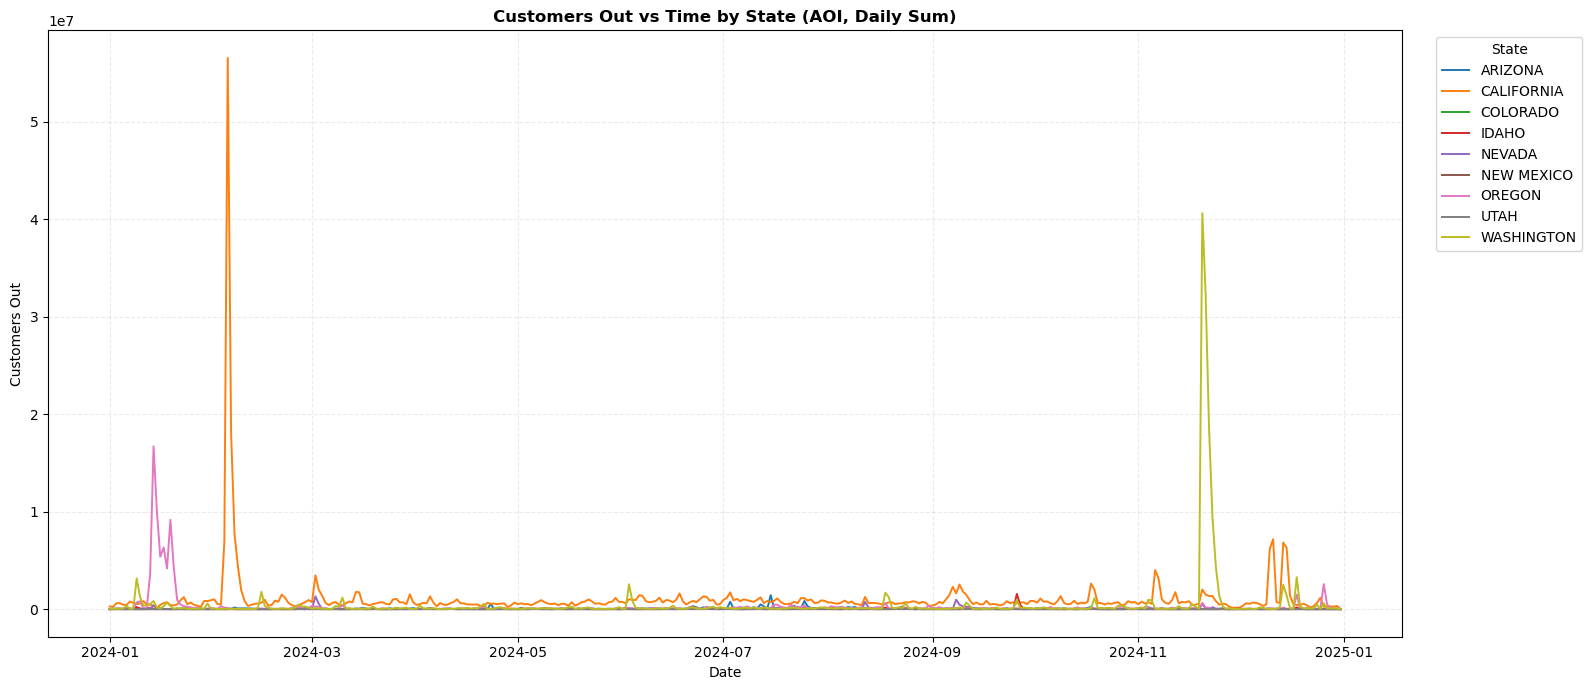

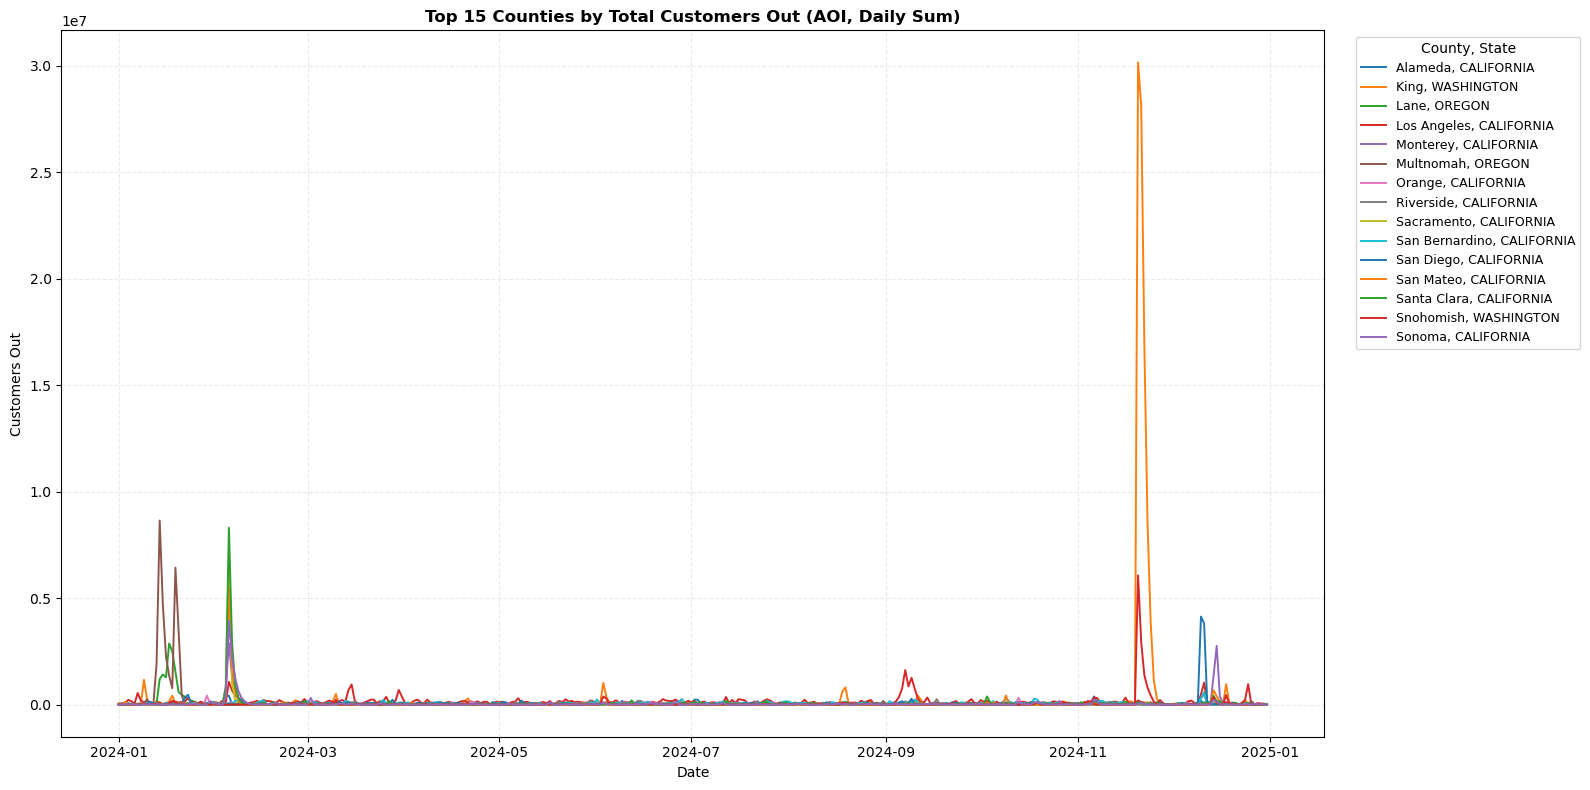


Top 15 counties by total customers out:


,county,state,customers_out
0,King,WASHINGTON,105886742
1,Los Angeles,CALIFORNIA,51783592
2,Multnomah,OREGON,34670151
3,Santa Clara,CALIFORNIA,26477925
4,San Diego,CALIFORNIA,21805756
5,San Bernardino,CALIFORNIA,20646723
6,Snohomish,WASHINGTON,16757819
7,San Mateo,CALIFORNIA,16468148
8,Monterey,CALIFORNIA,14924641
9,Sonoma,CALIFORNIA,14923137


In [33]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def _normalize_filtered_fips(x):
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    return s.lstrip("0")

def build_county_fips(counties_gdf):
    cg = counties_gdf.copy()

    # counties_gdf STATE like "06" should become "6" to match filtered_data
    state_part = cg["STATE"].astype(str).str.strip().str.lstrip("0")
    county_part = cg["COUNTY"].astype(str).str.strip().str.zfill(3)

    cg["fips_code"] = state_part + county_part
    return cg

def prepare_filtered_data_for_aoi(filtered_data, gdf_aoi, counties_gdf):
    df = filtered_data.copy()
    cg = build_county_fips(counties_gdf)

    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    df["customers_out"] = pd.to_numeric(df["customers_out"], errors="coerce")
    df["fips_code"] = df["fips_code"].map(_normalize_filtered_fips)

    # merge outage rows onto county geometries
    gdf = cg[["fips_code", "geometry"]].merge(df, on="fips_code", how="inner")
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=cg.crs)

    gdf["state"] = gdf["state"].astype(str).str.strip().str.upper()
    gdf["county"] = gdf["county"].astype(str).str.strip()

    # dissolve AOI to avoid duplicate matches
    aoi = gdf_aoi[["geometry"]].to_crs(gdf.crs).dissolve().reset_index(drop=True)

    gdf_aoi_clipped = gpd.sjoin(
        gdf,
        aoi,
        how="inner",
        predicate="intersects",
    ).drop(columns=["index_right"], errors="ignore")

    gdf_aoi_clipped = gdf_aoi_clipped.dropna(subset=["datetime", "customers_out"]).copy()
    return gdf_aoi_clipped

filtered_data_aoi = prepare_filtered_data_for_aoi(
    filtered_data=filtered_data,
    gdf_aoi=gdf_aoi,
    counties_gdf=counties_gdf,
)

print(f"AOI rows: {len(filtered_data_aoi)}")
print(f"States: {sorted(filtered_data_aoi['state'].unique())}")
print(f"Date range: {filtered_data_aoi['datetime'].min()} -> {filtered_data_aoi['datetime'].max()}")

# Daily aggregation for readability across the full year
state_ts = (
    filtered_data_aoi
    .groupby(["state", pd.Grouper(key="datetime", freq="1D")])["customers_out"]
    .sum()
    .reset_index()
)

state_pivot = (
    state_ts
    .pivot(index="datetime", columns="state", values="customers_out")
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(16, 7))
for state in state_pivot.columns:
    ax.plot(state_pivot.index, state_pivot[state], linewidth=1.4, label=state)

ax.set_title("Customers Out vs Time by State (AOI, Daily Sum)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Customers Out")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="State", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

top15_counties = (
    filtered_data_aoi
    .groupby(["county", "state"], as_index=False)["customers_out"]
    .sum()
    .sort_values("customers_out", ascending=False)
    .head(15)
    .copy()
)

top15_series = filtered_data_aoi.merge(
    top15_counties[["county", "state"]],
    on=["county", "state"],
    how="inner",
)

county_ts = (
    top15_series
    .groupby(["county", "state", pd.Grouper(key="datetime", freq="1D")])["customers_out"]
    .sum()
    .reset_index()
    .sort_values("datetime")
)

fig, ax = plt.subplots(figsize=(16, 8))
for (county, state), grp in county_ts.groupby(["county", "state"]):
    ax.plot(
        grp["datetime"],
        grp["customers_out"],
        linewidth=1.4,
        label=f"{county}, {state}",
    )

ax.set_title("Top 15 Counties by Total Customers Out (AOI, Daily Sum)", fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Customers Out")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="County, State", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 15 counties by total customers out:")
display(top15_counties.reset_index(drop=True))


In [22]:
import plotly.express as px

# ---------------------------
# Plotly 1: state time series
# ---------------------------
state_ts_plotly = (
    filtered_data_aoi
    .groupby(["state", pd.Grouper(key="datetime", freq="1D")])["customers_out"]
    .sum()
    .reset_index()
    .sort_values(["state", "datetime"])
)

fig_state = px.line(
    state_ts_plotly,
    x="datetime",
    y="customers_out",
    color="state",
    title="Customers Out vs Time by State (AOI, Daily Sum)",
    # log_y=True,
    labels={
        "datetime": "Date",
        "customers_out": "Customers Out",
        "state": "State",
    },
    template="plotly_white",
)

fig_state.update_traces(mode="lines")
fig_state.update_layout(
    width=1200,
    height=550,
    hovermode="x unified",
    legend_title_text="State",
)

fig_state.show()

# -----------------------------------------
# Plotly 2: top 15 counties through the year
# -----------------------------------------
top15_counties_plotly = (
    filtered_data_aoi
    .groupby(["county", "state"], as_index=False)["customers_out"]
    .sum()
    .sort_values("customers_out", ascending=False)
    .head(15)
    .copy()
)

top15_series_plotly = filtered_data_aoi.merge(
    top15_counties_plotly[["county", "state"]],
    on=["county", "state"],
    how="inner",
)

county_ts_plotly = (
    top15_series_plotly
    .groupby(["county", "state", pd.Grouper(key="datetime", freq="1D")])["customers_out"]
    .sum()
    .reset_index()
    .sort_values(["state", "county", "datetime"])
)

county_ts_plotly["county_state"] = (
    county_ts_plotly["county"].astype(str) + ", " + county_ts_plotly["state"].astype(str)
)

fig_county = px.line(
    county_ts_plotly,
    x="datetime",
    y="customers_out",
    color="county_state",
    title="Top 15 Counties by Total Customers Out (AOI, Daily Sum)",
    # log_y=True,
    labels={
        "datetime": "Date",
        "customers_out": "Customers Out",
        "county_state": "County, State",
    },
    template="plotly_white",
)

fig_county.update_traces(mode="lines")
fig_county.update_layout(
    width=1200,
    height=650,
    hovermode="x unified",
    legend_title_text="County, State",
)

fig_county.show()

display(top15_counties_plotly.reset_index(drop=True))


,county,state,customers_out
0,King,WASHINGTON,105886742
1,Los Angeles,CALIFORNIA,51783592
2,Multnomah,OREGON,34670151
3,Santa Clara,CALIFORNIA,26477925
4,San Diego,CALIFORNIA,21805756
5,San Bernardino,CALIFORNIA,20646723
6,Snohomish,WASHINGTON,16757819
7,San Mateo,CALIFORNIA,16468148
8,Monterey,CALIFORNIA,14924641
9,Sonoma,CALIFORNIA,14923137


In [ ]:
# marking key dates

columns=['dates','attribution','reference']

wildfire_dates = pd.DataFrame(columns=columns)
terrwx_dates = pd.DataFrame(columns=columns)
spwx_dates = pd.DataFrame(columns=columns)

# Adding wildfire events
6/15/2024 - Post Fire
6/24/2024 - Fresno June Lightning Complex
7/05/2024 - Lake Fire
7/13/2024 - 2024 SQF Lightning Complex
7/24/2024 - Park Fire - https://www.fire.ca.gov/incidents/2024/7/24/park-fire

7/24/2024 - Borel Fire - 
9/05/2024 - Line Fire
9/08/2024 - Bridge Fire - 
9/09/2024 - Airport Fire - 


# Adding terrestrial weather events
terrwx_dates.loc[len(terrwx_dates)] = {
	'dates': ['2024-02-05'],
	'attribution': 'atmospheric river',
    'reference': 'https://www.reuters.com/world/us/atmospheric-river-storm-leaves-over-600000-still-without-power-california-2024-02-05/'
}

terrwx_dates.loc[len(terrwx_dates)] = {
	'dates': ['2024-09-01','2024-09-20'],
	'attribution': 'heat wave'
    'reference': 'https://www.climate.gov/news-features/event-tracker/heat-wave-southern-california-and-southwest-early-september-2024'
}
07/01/2024-07/15/2024 - 'heat wave'


# Adding space weather events
05/10/2024-05/20/2024 - Gannon storm
06/29/2024-6/30/2024 - CME
08/12/2024-08/14/2024 - CME
09/13/2024-09/20/2024 - CME
10/15/2024-10/18/2024 - CME

# terrestrial_dates = ['02-05-2024','atmospheric river']
# spwx_dates = ['05-','Gannon storm']

# Wildfire: here are the CalFire incidents in 2024. June-September inclusive might be a compelling period
# Terrestrial weather: record rainfall in southern CA February 2024 (+atmospheric rivers), unusually hot temps in northern CA in October, 
# Space weather: May 10 (Gannon Storm), June 29-30, August 12-14, September 13-20, October 15-18
# Power grid: large and geographically spread outages in January and November 18-27, LA outages in March and September 2-20, King county outages June 2 and August 15-20

In [30]:

# Standardized schema: start_date, end_date, attribution, reference
columns = ["start_date", "end_date", "attribution", "reference"]

wildfire_dates = pd.DataFrame([
    {"start_date": "2024-06-15", "end_date": "2024-06-15", "attribution": "Post Fire", "reference": ""},
    {"start_date": "2024-06-24", "end_date": "2024-06-24", "attribution": "Fresno June Lightning Complex", "reference": ""},
    {"start_date": "2024-07-05", "end_date": "2024-07-05", "attribution": "Lake Fire", "reference": ""},
    {"start_date": "2024-07-13", "end_date": "2024-07-13", "attribution": "2024 SQF Lightning Complex", "reference": ""},
    {"start_date": "2024-07-24", "end_date": "2024-07-24", "attribution": "Park Fire", "reference": "https://www.fire.ca.gov/incidents/2024/7/24/park-fire"},
    {"start_date": "2024-07-24", "end_date": "2024-07-24", "attribution": "Borel Fire", "reference": ""},
    {"start_date": "2024-09-05", "end_date": "2024-09-05", "attribution": "Line Fire", "reference": ""},
    {"start_date": "2024-09-08", "end_date": "2024-09-08", "attribution": "Bridge Fire", "reference": ""},
    {"start_date": "2024-09-09", "end_date": "2024-09-09", "attribution": "Airport Fire", "reference": ""},
], columns=columns)

terrwx_dates = pd.DataFrame([
    {"start_date": "2024-02-05", "end_date": "2024-02-05", "attribution": "Atmospheric river", "reference": "https://www.reuters.com/world/us/atmospheric-river-storm-leaves-over-600000-still-without-power-california-2024-02-05/"},
    {"start_date": "2024-09-01", "end_date": "2024-09-20", "attribution": "Heat wave", "reference": "https://www.climate.gov/news-features/event-tracker/heat-wave-southern-california-and-southwest-early-september-2024"},
    {"start_date": "2024-07-01", "end_date": "2024-07-15", "attribution": "Heat wave", "reference": ""},
], columns=columns)

spwx_dates = pd.DataFrame([
    {"start_date": "2024-05-10", "end_date": "2024-05-20", "attribution": "Gannon storm", "reference": ""},
    {"start_date": "2024-06-29", "end_date": "2024-06-30", "attribution": "CME", "reference": ""},
    {"start_date": "2024-08-12", "end_date": "2024-08-14", "attribution": "CME", "reference": ""},
    {"start_date": "2024-09-13", "end_date": "2024-09-20", "attribution": "CME", "reference": ""},
    {"start_date": "2024-10-15", "end_date": "2024-10-18", "attribution": "CME", "reference": ""},
], columns=columns)

for df_ in [wildfire_dates, terrwx_dates, spwx_dates]:
    df_["start_date"] = pd.to_datetime(df_["start_date"])
    df_["end_date"] = pd.to_datetime(df_["end_date"])

def add_event_overlays(fig, events_df, color):
    for _, r in events_df.iterrows():
        s, e = r["start_date"], r["end_date"]
        if s.normalize() == e.normalize():
            # single-day event -> vertical bar
            fig.add_vline(x=s, line_width=1.5, line_dash="dot", line_color=color, opacity=0.9)
        else:
            # multi-day event -> shaded band
            fig.add_vrect(
                x0=s,
                x1=e + pd.Timedelta(days=1),  # include end day
                fillcolor=color,
                opacity=0.12,
                line_width=0,
                layer="below",
            )

# Apply overlays to existing plotly figures from prior cell
add_event_overlays(fig_state, wildfire_dates, "#d95f02")  # wildfire
add_event_overlays(fig_state, terrwx_dates,  "#1f78b4")   # terrestrial weather
add_event_overlays(fig_state, spwx_dates,    "#6a3d9a")   # space weather

add_event_overlays(fig_county, wildfire_dates, "#d95f02")
add_event_overlays(fig_county, terrwx_dates,  "#1f78b4")
add_event_overlays(fig_county, spwx_dates,    "#6a3d9a")

# Legend proxies for event categories
for fig in [fig_state, fig_county]:
    fig.add_scatter(x=[None], y=[None], mode="markers", marker=dict(size=10, color="#d95f02"), name="Wildfire events")
    fig.add_scatter(x=[None], y=[None], mode="markers", marker=dict(size=10, color="#1f78b4"), name="Terrestrial weather events")
    fig.add_scatter(x=[None], y=[None], mode="markers", marker=dict(size=10, color="#6a3d9a"), name="Space weather events")

fig_state.show()
fig_county.show()

display(wildfire_dates)
display(terrwx_dates)
display(spwx_dates)


,start_date,end_date,attribution,reference
0,2024-06-15,2024-06-15,Post Fire,
1,2024-06-24,2024-06-24,Fresno June Lightning Complex,
2,2024-07-05,2024-07-05,Lake Fire,
3,2024-07-13,2024-07-13,2024 SQF Lightning Complex,
4,2024-07-24,2024-07-24,Park Fire,https://www.fire.ca.gov/incidents/2024/7/24/pa...
5,2024-07-24,2024-07-24,Borel Fire,
6,2024-09-05,2024-09-05,Line Fire,
7,2024-09-08,2024-09-08,Bridge Fire,
8,2024-09-09,2024-09-09,Airport Fire,


,start_date,end_date,attribution,reference
0,2024-02-05,2024-02-05,Atmospheric river,https://www.reuters.com/world/us/atmospheric-r...
1,2024-09-01,2024-09-20,Heat wave,https://www.climate.gov/news-features/event-tr...
2,2024-07-01,2024-07-15,Heat wave,


,start_date,end_date,attribution,reference
0,2024-05-10,2024-05-20,Gannon storm,
1,2024-06-29,2024-06-30,CME,
2,2024-08-12,2024-08-14,CME,
3,2024-09-13,2024-09-20,CME,
4,2024-10-15,2024-10-18,CME,


In [31]:
# add PSPS events
psps_events = '/Users/ryanmc/Documents/Conferences/Jack_Eddy_Symposium_2022/dev/outage_data/CPUC_CA_2024_PSPSevents.csv'

In [ ]:
=import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- PSPS data ---
psps_df = pd.read_csv(psps_events)

required_cols = ["event_name", "first_date_of_poc", "customers_de_energized"]
missing = [c for c in required_cols if c not in psps_df.columns]
if missing:
    raise ValueError(f"Missing PSPS columns: {missing}")

psps_df = psps_df[required_cols].copy()
psps_df["first_date_of_poc"] = pd.to_datetime(psps_df["first_date_of_poc"], errors="coerce")
psps_df["customers_de_energized"] = pd.to_numeric(psps_df["customers_de_energized"], errors="coerce")
psps_df = psps_df.dropna(subset=["first_date_of_poc", "customers_de_energized"])

# Optional: combine multiple events on same day
psps_daily = (
    psps_df.groupby("first_date_of_poc", as_index=False)["customers_de_energized"]
    .sum()
    .sort_values("first_date_of_poc")
)

# --- Build 3-row figure with tied x-axes ---
fig_3row = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=(
        "Customers Out vs Time by State (AOI, Daily Sum)",
        "Top 15 Counties by Total Customers Out (AOI, Daily Sum)",
        "PSPS Customers De-Energized"
    )
)

# Row 1: states
for state in state_ts_plotly["state"].dropna().unique():
    s = state_ts_plotly[state_ts_plotly["state"] == state]
    fig_3row.add_trace(
        go.Scatter(
            x=s["datetime"], y=s["customers_out"],
            mode="lines", name=f"State: {state}",
            legendgroup=f"state_{state}"
        ),
        row=1, col=1
    )

# Row 2: top 15 counties
for county_state in county_ts_plotly["county_state"].dropna().unique():
    c = county_ts_plotly[county_ts_plotly["county_state"] == county_state]
    fig_3row.add_trace(
        go.Scatter(
            x=c["datetime"], y=c["customers_out"],
            mode="lines", name=f"County: {county_state}",
            legendgroup=f"county_{county_state}"
        ),
        row=2, col=1
    )

# Row 3: PSPS bars
fig_3row.add_trace(
    go.Bar(
        x=psps_daily["first_date_of_poc"],
        y=psps_daily["customers_de_energized"],
        name="PSPS customers_de_energized",
        marker_color="#444"
    ),
    row=3, col=1
)

# Optional event overlays (if your event dfs already exist)
if "wildfire_dates" in globals():
    add_event_overlays(fig_3row, wildfire_dates, "#d95f02")
if "terrwx_dates" in globals():
    add_event_overlays(fig_3row, terrwx_dates, "#1f78b4")
if "spwx_dates" in globals():
    add_event_overlays(fig_3row, spwx_dates, "#6a3d9a")

fig_3row.update_yaxes(title_text="Customers Out", row=1, col=1)
fig_3row.update_yaxes(title_text="Customers Out", row=2, col=1)
fig_3row.update_yaxes(title_text="Customers De-Energized", row=3, col=1)
fig_3row.update_xaxes(title_text="Date", row=3, col=1)

fig_3row.update_layout(
    height=1000,
    width=1300,
    template="plotly_white",
    hovermode="x unified",
    title="AOI Outages + PSPS (Shared Time Axis)",
    legend_title_text="Series"
)

fig_3row.show()
=